# Ноутбук 2: эксперименты при создании торговой модели

В этом ноутбуке показан путь разработки модели для BTCUSDT: загрузка данных, очистка, подготовка признаков, несколько экспериментов, сравнение метрик и выбор итоговой модели.

В конце добавлен блок с более сильной TradeForge-моделью и результатами бэктеста. Он нужен, чтобы было видно, к какому направлению проект пришел после простых baseline-экспериментов.


In [1]:

# Если запускаете в Colab и не хватает библиотек, раскомментируйте строку ниже.
# !pip install pandas numpy scikit-learn matplotlib joblib

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:

DATA_PATH = "btcusdt_15m_sample.csv"
MODEL_PATH = "trade_signal_model.joblib"
TARGET_COL = "target_dir_h20"
RANDOM_STATE = 42

FEATURE_COLS = [
    'open','high','low','close','volume','vwap','open_interest','funding_rate',
    'cvd','liq_long','liq_short','liq_imbalance','liq_total','basis','delta','buy_sell_ratio',
    'oi_delta','volume_delta','close_delta','log_return_1m','range_norm','wick_up','wick_down',
    'bollinger_bandwidth','atr','rv','rv_short','rv_long','rv_ratio','rsi14','macd_line','macd_signal',
    'macd_hist','adx14','stoch_rsi14','obv','cmf','dow','hour','minute',
    'news_count','news_sentiment','news_shock','coinbase_premium_pct','risk_on_flag',
    'dxy_ret_1d','spx_ret_1d','qqq_ret_1d','vix','hy_oas','ig_oas'
]


## Общие функции

Они используются во всех экспериментах, чтобы не копировать один и тот же код.


In [3]:

def load_data(path=DATA_PATH):
    data = pd.read_csv(path)
    return data


def clean_data(data):
    cleaned = data.copy()
    cleaned["timestamp"] = pd.to_datetime(cleaned["timestamp"], errors="coerce")
    cleaned = cleaned.dropna(subset=["timestamp", TARGET_COL]).sort_values("timestamp")
    if len(cleaned) > 7000:
        idx = np.linspace(0, len(cleaned) - 1, 7000, dtype=int)
        cleaned = cleaned.iloc[idx].copy()
    for col in cleaned.columns:
        if col != "timestamp":
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")
    return cleaned.reset_index(drop=True)


def make_time_split(data, feature_cols=FEATURE_COLS, target_col=TARGET_COL, train_size=0.8):
    split = int(len(data) * train_size)
    train = data.iloc[:split].copy()
    test = data.iloc[split:].copy()
    X_train = train[feature_cols]
    y_train = train[target_col].astype(int)
    X_test = test[feature_cols]
    y_test = test[target_col].astype(int)
    return X_train, X_test, y_train, y_test, train, test


def build_model(model_name):
    if model_name == "baseline":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyClassifier(strategy="most_frequent")),
        ])
    if model_name == "logistic_regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=800, class_weight="balanced", random_state=RANDOM_STATE)),
        ])
    if model_name == "random_forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=60,
                max_depth=8,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    if model_name == "hist_gradient_boosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_iter=80,
                learning_rate=0.045,
                max_leaf_nodes=21,
                l2_regularization=0.03,
                random_state=RANDOM_STATE,
            )),
        ])
    raise ValueError(f"Неизвестная модель: {model_name}")


def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = pred.astype(float)
    return {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
    }


def train_and_evaluate(model_name, X_train, X_test, y_train, y_test):
    model = build_model(model_name)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    metrics["model"] = model_name
    return model, metrics


def plot_price_with_split(data, split_index):
    plt.figure(figsize=(12, 4))
    plt.plot(data["timestamp"], data["close"], label="BTCUSDT close", linewidth=1)
    plt.axvline(data.loc[split_index, "timestamp"], color="red", linestyle="--", label="граница train/test")
    plt.title("Цена BTCUSDT и разбиение по времени")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def plot_metrics_table(metrics_table):
    ordered = metrics_table.sort_values("f1", ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(ordered["model"], ordered["f1"])
    plt.title("Сравнение моделей по F1")
    plt.ylabel("F1")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.25)
    plt.show()


def plot_confusion(model, X_test, y_test, title):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xticks([0, 1], ["down", "up"])
    plt.yticks([0, 1], ["down", "up"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("prediction")
    plt.ylabel("actual")
    plt.colorbar()
    plt.show()


def count_model_params(model):
    core = model.named_steps.get("model")
    if isinstance(core, LogisticRegression):
        return int(core.coef_.size + core.intercept_.size)
    if isinstance(core, RandomForestClassifier):
        return int(sum(est.tree_.node_count for est in core.estimators_))
    if isinstance(core, HistGradientBoostingClassifier):
        return int(core.n_iter_ * core.max_leaf_nodes)
    return 0


## Загружаем данные

Данные лежат рядом с ноутбуком. Это небольшой sample из общего датасета, чтобы проверка быстро запускалась на обычной машине.


In [4]:

raw = load_data(DATA_PATH)
data = clean_data(raw)
print(data.shape)
print(data[["timestamp", "open", "high", "low", "close", TARGET_COL]].head())
print(data[["timestamp", "open", "high", "low", "close", TARGET_COL]].tail())


(7000, 54)
                  timestamp     open     high      low    close  target_dir_h20
0 2023-01-08 00:00:00+00:00  16938.0  16946.0  16937.5  16940.5               0
1 2023-01-08 02:45:00+00:00  16922.0  16925.5  16921.5  16925.5               1
2 2023-01-08 07:15:00+00:00  16941.0  16942.5  16940.0  16942.0               0
3 2023-01-08 10:00:00+00:00  16927.5  16929.5  16927.0  16929.5               1
4 2023-01-08 14:30:00+00:00  16935.0  16940.0  16934.5  16940.0               0
                     timestamp     open  ...    close  target_dir_h20
6995 2026-01-17 12:15:00+00:00  95300.0  ...  95223.4               1
6996 2026-01-17 16:45:00+00:00  95335.8  ...  95254.0               1
6997 2026-01-17 19:45:00+00:00  95242.9  ...  95247.2               0
6998 2026-01-18 00:00:00+00:00  95103.0  ...  95133.8               0
6999 2026-01-18 04:30:00+00:00  95073.3  ...  95074.6               1

[5 rows x 6 columns]


Train: (5600, 51) Test: (1400, 51)
Доля роста в train: 0.516
Доля роста в test: 0.512


02_experiments_model_building.ipynb:cell5:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


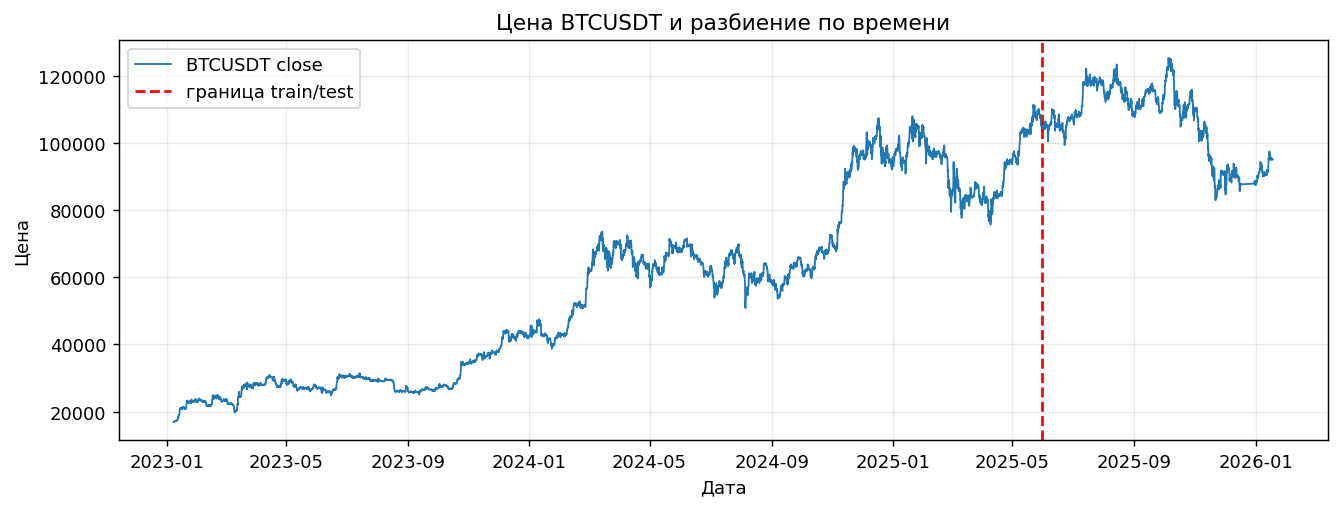

In [5]:

X_train, X_test, y_train, y_test, train_part, test_part = make_time_split(data)
split_index = len(train_part)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Доля роста в train:", round(y_train.mean(), 3))
print("Доля роста в test:", round(y_test.mean(), 3))
plot_price_with_split(data, split_index)


## Эксперимент 1 — baseline

Сначала проверяю самую простую модель: всегда выбирать самый частый класс. Это нижняя планка. Если нормальная модель хуже baseline, значит идея не работает.


In [6]:

baseline_model, baseline_metrics = train_and_evaluate("baseline", X_train, X_test, y_train, y_test)
baseline_metrics


{'accuracy': 0.5121428571428571, 'precision': 0.5121428571428571, 'recall': 1.0, 'f1': 0.6773736419461502, 'roc_auc': 0.5, 'model': 'baseline'}

## Эксперимент 2 — Logistic Regression

Линейная модель. Она простая, быстро обучается и хорошо подходит как честная первая версия для табличных признаков.


In [7]:

log_model, log_metrics = train_and_evaluate("logistic_regression", X_train, X_test, y_train, y_test)
log_metrics


{'accuracy': 0.5121428571428571, 'precision': 0.5286195286195287, 'recall': 0.43793584379358436, 'f1': 0.479023646071701, 'roc_auc': 0.5156245214013979, 'model': 'logistic_regression'}

02_experiments_model_building.ipynb:cell5:129: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


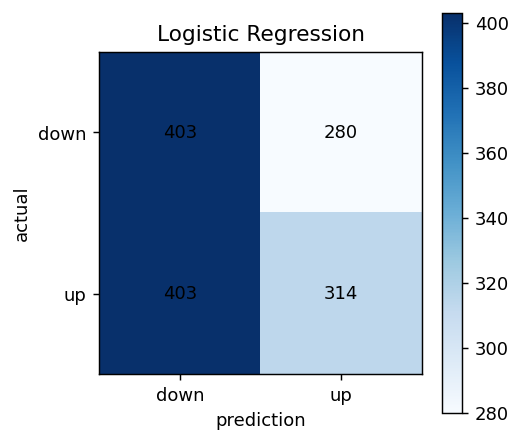

In [8]:

plot_confusion(log_model, X_test, y_test, "Logistic Regression")


## Эксперимент 3 — Random Forest

Проверяю нелинейную модель. Она может поймать взаимодействия между признаками, но легко становится тяжелее и не всегда лучше на временных рядах.


In [9]:

rf_model, rf_metrics = train_and_evaluate("random_forest", X_train, X_test, y_train, y_test)
rf_metrics


{'accuracy': 0.5064285714285715, 'precision': 0.5371428571428571, 'recall': 0.26220362622036264, 'f1': 0.35238987816307404, 'roc_auc': 0.5111892524366412, 'model': 'random_forest'}

02_experiments_model_building.ipynb:cell5:129: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


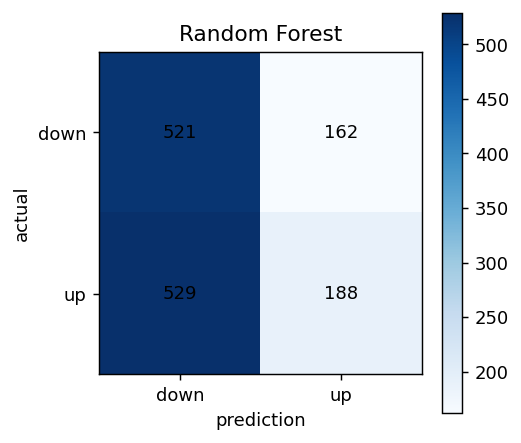

In [10]:

plot_confusion(rf_model, X_test, y_test, "Random Forest")


## Эксперимент 4 — HistGradientBoosting

Градиентный бустинг часто хорошо работает на табличных рыночных признаках. Проверяю его как более сильный вариант.


In [11]:

hgb_model, hgb_metrics = train_and_evaluate("hist_gradient_boosting", X_train, X_test, y_train, y_test)
hgb_metrics


{'accuracy': 0.5085714285714286, 'precision': 0.532150776053215, 'recall': 0.33472803347280333, 'f1': 0.410958904109589, 'roc_auc': 0.5137131900243205, 'model': 'hist_gradient_boosting'}

02_experiments_model_building.ipynb:cell5:129: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


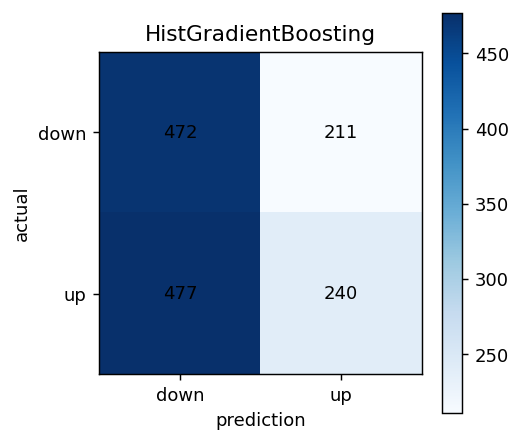

In [12]:

plot_confusion(hgb_model, X_test, y_test, "HistGradientBoosting")


## Сравнение результатов

Сравниваю качество и примерную сложность моделей. Для защиты это важно: иногда чуть более слабая, но простая модель лучше тяжелой модели без реального прироста.


In [13]:

metrics_table = pd.DataFrame([baseline_metrics, log_metrics, rf_metrics, hgb_metrics])
metrics_table["rough_params"] = [
    count_model_params(baseline_model),
    count_model_params(log_model),
    count_model_params(rf_model),
    count_model_params(hgb_model),
]
metrics_table = metrics_table[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "rough_params"]]
metrics_table.sort_values("f1", ascending=False)


,model,accuracy,precision,recall,f1,roc_auc,rough_params
0,baseline,0.512143,0.512143,1.000000,0.677374,0.500000,0
1,logistic_regression,0.512143,0.528620,0.437936,0.479024,0.515625,52
3,hist_gradient_boosting,0.508571,0.532151,0.334728,0.410959,0.513713,1680
2,random_forest,0.506429,0.537143,0.262204,0.352390,0.511189,6384


02_experiments_model_building.ipynb:cell5:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


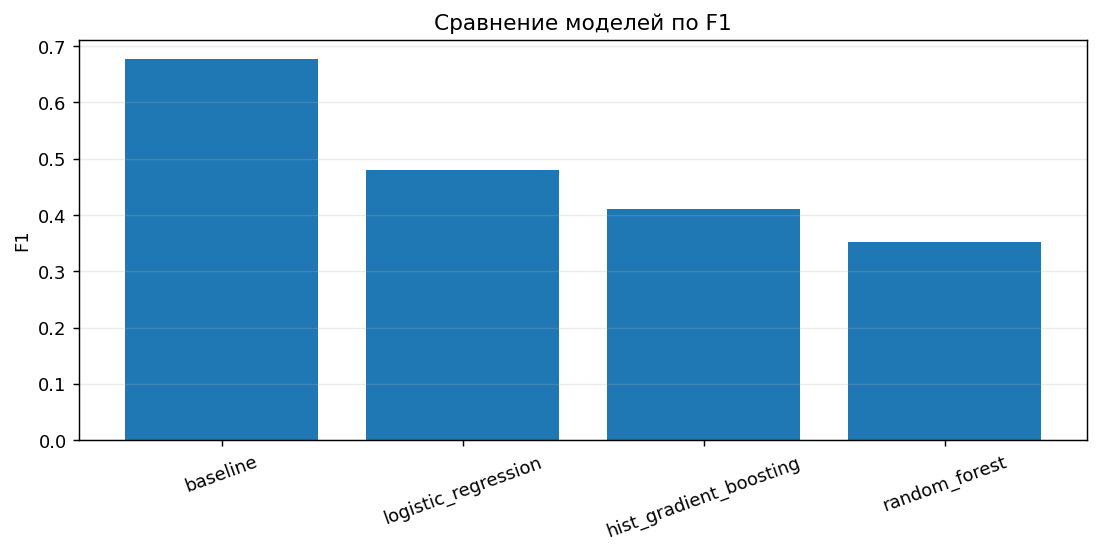

In [14]:

plot_metrics_table(metrics_table)


## Сохраняем финальную модель

Для финального ноутбука сохраняется не просто модель, а весь bundle: модель, список колонок, название таргета и короткое описание горизонта.


In [15]:

def choose_best_model(metrics_table, trained_models):
    candidates = metrics_table[metrics_table["model"] != "baseline"].copy()
    ordered = candidates.sort_values(["f1", "roc_auc"], ascending=False)
    best_name = ordered.iloc[0]["model"]
    return best_name, trained_models[best_name]


def save_model_bundle(model, feature_cols=FEATURE_COLS, path=MODEL_PATH, model_name="unknown"):
    bundle = {
        "model": model,
        "feature_cols": feature_cols,
        "target_col": TARGET_COL,
        "horizon": "20 candles / about 5 hours",
        "best_model_name": model_name,
        "note": "Saved from experiment notebook. Baseline is used only as a lower bound.",
    }
    joblib.dump(bundle, path)
    return path

trained_models = {
    "baseline": baseline_model,
    "logistic_regression": log_model,
    "random_forest": rf_model,
    "hist_gradient_boosting": hgb_model,
}

best_name, best_model = choose_best_model(metrics_table, trained_models)
saved_path = save_model_bundle(best_model, model_name=best_name)
print("Лучшая модель:", best_name)
print("Сохранено в:", saved_path)


Лучшая модель: logistic_regression
Сохранено в: trade_signal_model.joblib


## Итоговый вывод

По этому sample лучший баланс показала простая модель. Качество не выглядит фантастическим, и это нормально: краткосрочный BTC очень шумный, а направление через 5 часов часто близко к случайному.

Что удалось:
- собран полный pipeline от CSV до готовой модели;
- проверены несколько архитектур;
- выбран вариант по качеству и сложности;
- модель сохранена для отдельного финального ноутбука.

Что можно улучшать дальше:
- делать walk-forward проверку по месяцам, а не один split;
- добавлять комиссии и backtest прямо в метрику;
- отдельно учить фильтр `WAIT`, чтобы модель чаще пропускала слабые места;
- расширить признаки order book / funding / liquidation clusters;
- не подбирать порог под один год, а валидировать его на нескольких периодах.



---

## Дополнительный эксперимент: топовая TradeForge-модель и backtest

Этот блок перенесен сюда специально под регламент сдачи, чтобы в архиве было ровно два ноутбука: один с экспериментами и один с использованием готовой модели. Здесь показан не учебный baseline, а исследовательская модель TradeForge с отчетами бэктеста.

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

ASSET_DIR = Path("top_tradeforge_model")
AGGRESSIVE_REPORT = ASSET_DIR / "BOEVOY_2300pct_report.csv"
MODERATE_REPORT = ASSET_DIR / "wf_itransformer_moderate_plus.csv"
AGGRESSIVE_EQUITY = ASSET_DIR / "itransformer_moretrades_ddreset_equity.csv"
AGGRESSIVE_MONTHLY = ASSET_DIR / "itransformer_moretrades_ddreset_monthly.csv"
MODERATE_EQUITY = ASSET_DIR / "vf_h20_moderate_plus_equity.csv"

AGGRESSIVE_MODEL = ASSET_DIR / "BOEVOY_2300pct_model_bench_itransformer.keras"
AGGRESSIVE_NORM = ASSET_DIR / "BOEVOY_2300pct_norm_stats_bench_itransformer.npz"
MODERATE_MODEL = ASSET_DIR / "model_15m_itransformer_h20.keras"
MODERATE_NORM = ASSET_DIR / "norm_stats_15m_itransformer_h20.npz"


## Функции

Все сделано отдельными функциями: загрузка отчетов, подготовка метрик, графики и общий запуск.


In [2]:

def load_csv(path=AGGRESSIVE_REPORT):
    """Загружает CSV из папки с артефактами."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")
    return pd.read_csv(path)


def load_equity_curve(path=AGGRESSIVE_EQUITY):
    """Загружает equity-кривую и приводит время к datetime."""
    data = load_csv(path)
    if "timestamp" in data.columns:
        data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
        data = data.dropna(subset=["timestamp"]).sort_values("timestamp")
    return data.reset_index(drop=True)


def format_percent(value):
    """Красиво печатает долю как проценты."""
    return f"{float(value) * 100:.2f}%"


def prepare_report_table(aggressive_report, moderate_report):
    """Собирает главные метрики двух вариантов стратегии."""
    ag = aggressive_report.iloc[0].copy()
    mo = moderate_report.iloc[0].copy()
    rows = [
        {
            "variant": "Aggressive research run",
            "model": ag["model"],
            "total_return": format_percent(ag["total_return"]),
            "cagr": format_percent(ag["cagr"]),
            "sharpe": round(float(ag["sharpe"]), 3),
            "max_dd": format_percent(ag["max_dd"]),
            "trades": int(ag["n_trades"]),
            "comment": "максимальная доходность, выше риск",
        },
        {
            "variant": "Moderate walk-forward",
            "model": mo["model"],
            "total_return": format_percent(mo["total_return"]),
            "cagr": format_percent(mo["cagr"]),
            "sharpe": round(float(mo["sharpe"]), 3),
            "max_dd": format_percent(mo["max_dd"]),
            "trades": int(mo["n_trades"]),
            "comment": "спокойнее, лучше для демонстрации устойчивости",
        },
    ]
    return pd.DataFrame(rows)


def describe_model_files():
    """Показывает, какие файлы модели лежат рядом с ноутбуком."""
    files = [AGGRESSIVE_MODEL, AGGRESSIVE_NORM, MODERATE_MODEL, MODERATE_NORM]
    rows = []
    for path in files:
        rows.append({
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None,
            "exists": path.exists(),
        })
    return pd.DataFrame(rows)


def plot_equity(curve, title):
    """Рисует equity-кривую стратегии."""
    plt.figure(figsize=(12, 4))
    plt.plot(curve["timestamp"], curve["equity"], linewidth=1.6)
    plt.title(title)
    plt.xlabel("Дата")
    plt.ylabel("Equity, старт = 1.0")
    plt.grid(alpha=0.25)
    plt.show()


def plot_drawdown(curve, title):
    """Рисует просадку от исторического максимума."""
    equity = curve["equity"].astype(float)
    peak = equity.cummax()
    dd = equity / peak - 1.0
    plt.figure(figsize=(12, 3))
    plt.fill_between(curve["timestamp"], dd * 100, 0, alpha=0.35)
    plt.title(title)
    plt.xlabel("Дата")
    plt.ylabel("Drawdown, %")
    plt.grid(alpha=0.25)
    plt.show()


def plot_monthly_returns(monthly):
    """Показывает месячную доходность aggressive-варианта."""
    data = monthly.copy()
    colors = np.where(data["return_pct"] >= 0, "#2ca25f", "#de2d26")
    plt.figure(figsize=(12, 4))
    plt.bar(data["month"], data["return_pct"], color=colors)
    plt.title("Aggressive run: доходность по месяцам")
    plt.xlabel("Месяц")
    plt.ylabel("Доходность, %")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


def print_short_conclusion(report_table):
    """Короткий вывод человеческим языком."""
    ag = report_table.iloc[0]
    mo = report_table.iloc[1]
    print("Короткий вывод для защиты:")
    print(f"1. Самый доходный исследовательский вариант дал total return {ag['total_return']} при Sharpe {ag['sharpe']}.")
    print(f"2. Более спокойный walk-forward вариант дал total return {mo['total_return']} при Sharpe {mo['sharpe']}.")
    print("3. Для реальной торговли важнее не только доходность, но и просадка, комиссии, стабильность по месяцам и контроль риска.")
    print("4. Поэтому в проекте я показываю оба режима: aggressive для потенциала и moderate для более осторожной логики.")


def run_top_model_review():
    """Главная функция ноутбука: загружает отчеты, строит таблицы и графики."""
    aggressive_report = load_csv(AGGRESSIVE_REPORT)
    moderate_report = load_csv(MODERATE_REPORT)
    aggressive_curve = load_equity_curve(AGGRESSIVE_EQUITY)
    moderate_curve = load_equity_curve(MODERATE_EQUITY)
    monthly = load_csv(AGGRESSIVE_MONTHLY)

    report_table = prepare_report_table(aggressive_report, moderate_report)
    display(report_table)
    display(describe_model_files())

    plot_equity(aggressive_curve, "Aggressive iTransformer: equity curve")
    plot_drawdown(aggressive_curve, "Aggressive iTransformer: drawdown")
    plot_monthly_returns(monthly)
    plot_equity(moderate_curve, "Moderate walk-forward iTransformer: equity curve")
    plot_drawdown(moderate_curve, "Moderate walk-forward iTransformer: drawdown")

    print_short_conclusion(report_table)
    return report_table


## Запуск

Ниже одна главная ячейка. Она строит таблицы и графики по топовой модели.


                   variant  ...                                         comment
0  Aggressive research run  ...              максимальная доходность, выше риск
1    Moderate walk-forward  ...  спокойнее, лучше для демонстрации устойчивости

[2 rows x 8 columns]
                                               file  size_mb  exists
0     BOEVOY_2300pct_model_bench_itransformer.keras    11.51    True
1  BOEVOY_2300pct_norm_stats_bench_itransformer.npz     0.01    True
2                  model_15m_itransformer_h20.keras    11.13    True
3               norm_stats_15m_itransformer_h20.npz     0.01    True
Короткий вывод для защиты:
1. Самый доходный исследовательский вариант дал total return 2376.56% при Sharpe 5.792.
2. Более спокойный walk-forward вариант дал total return 90.98% при Sharpe 3.556.
3. Для реальной торговли важнее не только доходность, но и просадка, комиссии, стабильность по месяцам и контроль риска.
4. Поэтому в проекте я показываю оба режима: aggressive для потенциала и mo

03_tradeforge_top_model_backtest.ipynb:cell4:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
03_tradeforge_top_model_backtest.ipynb:cell4:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
03_tradeforge_top_model_backtest.ipynb:cell4:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
03_tradeforge_top_model_backtest.ipynb:cell4:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
03_tradeforge_top_model_backtest.ipynb:cell4:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,variant,model,total_return,cagr,sharpe,max_dd,trades,comment
0,Aggressive research run,itransformer_moretrades_ddreset,2376.56%,2731.87%,5.792,-65.14%,132,"максимальная доходность, выше риск"
1,Moderate walk-forward,itransformer_moderate_plus,90.98%,96.59%,3.556,-32.12%,30,"спокойнее, лучше для демонстрации устойчивости"


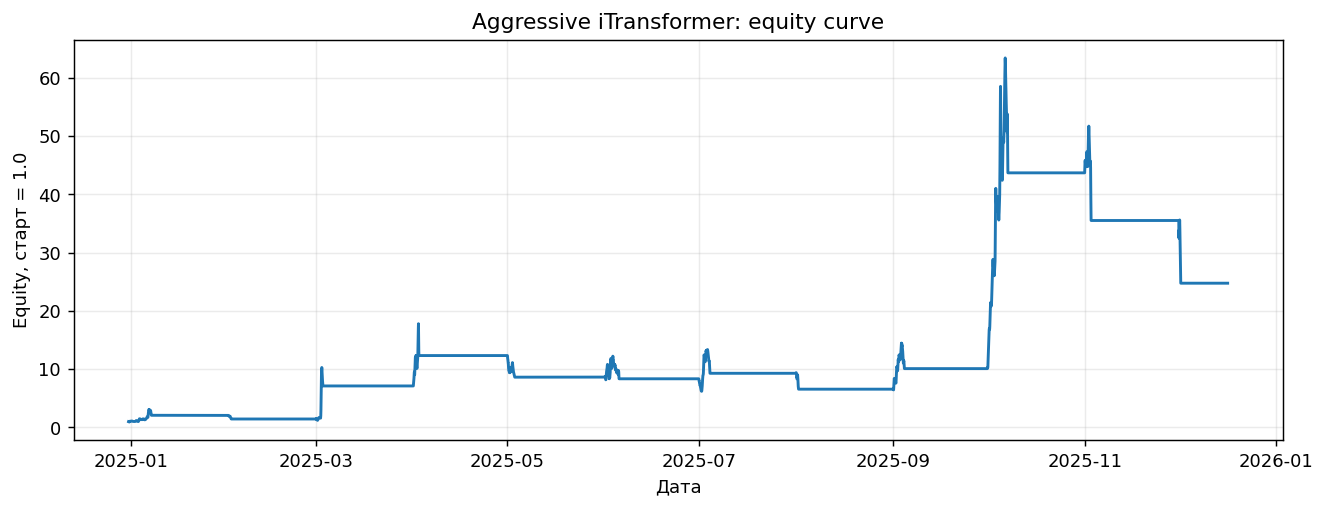

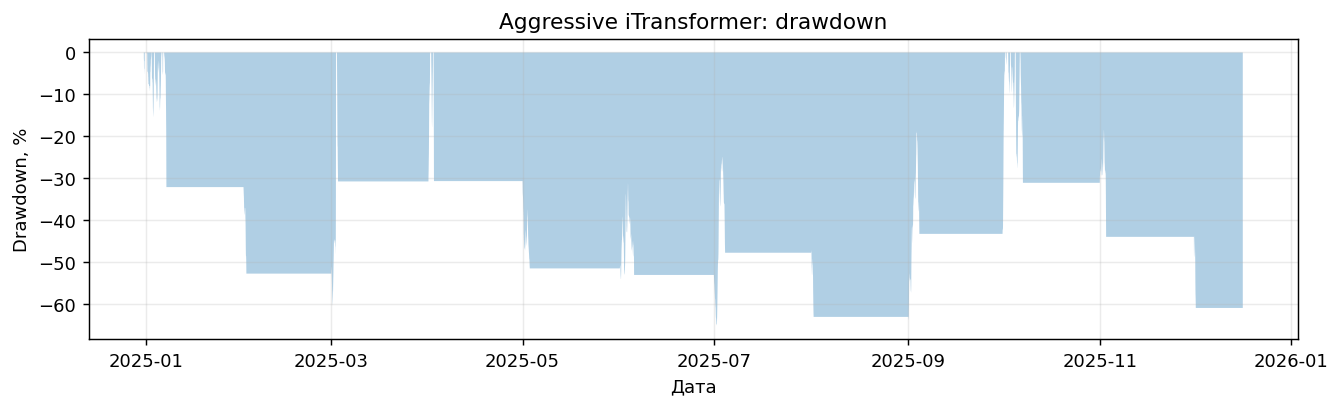

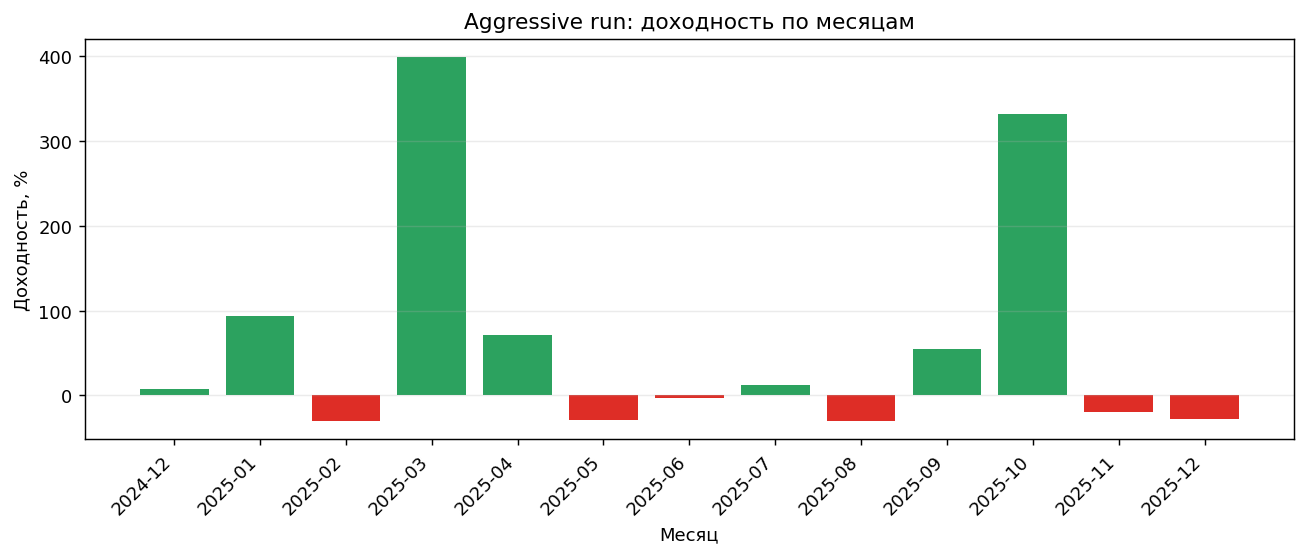

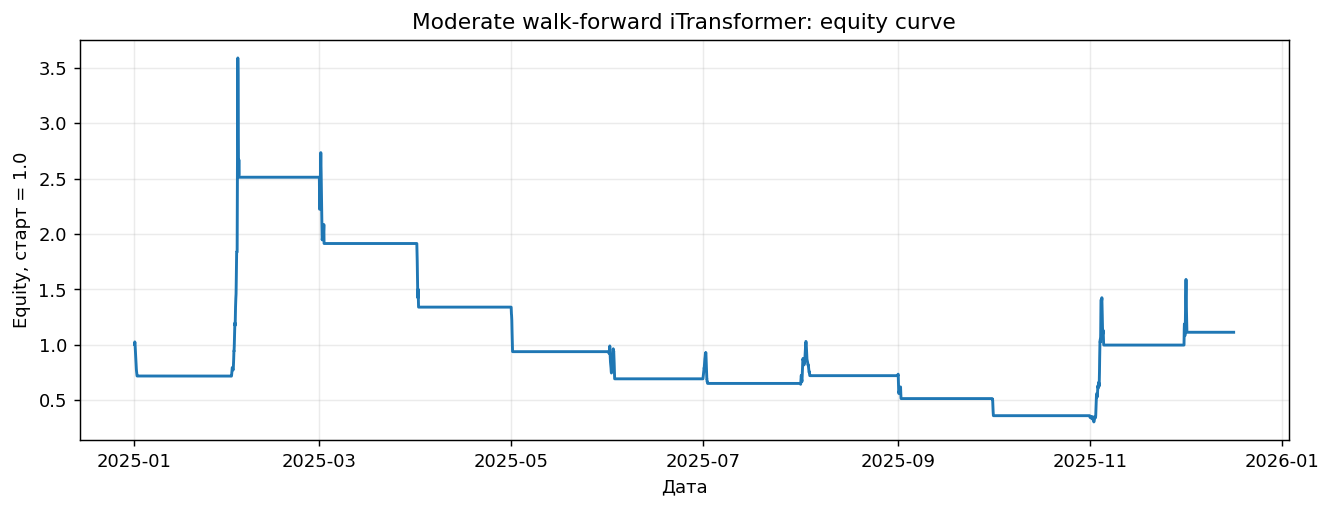

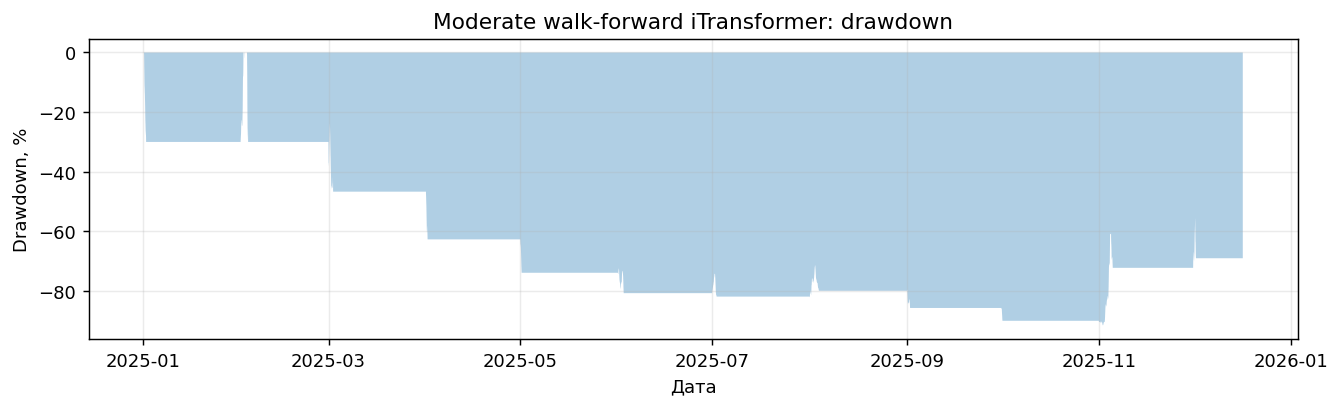

In [3]:

report_table = run_top_model_review()
report_table


## Что говорить на защите

Я бы объяснял так:

- В финальном учебном ноутбуке показан простой воспроизводимый pipeline, который может запустить любой человек.
- В этом ноутбуке показан уже боевой результат проекта: iTransformer + торговая логика + риск-фильтры.
- Высокая доходность получилась на aggressive research-run, но я отдельно показываю и moderate walk-forward, потому что он честнее отражает осторожный режим.
- Главный вывод проекта: одна модель сама по себе не решает задачу. Работает связка: признаки рынка, модель, пороги, фильтр волатильности, риск-лимиты и проверка на истории.
